# Mean-centred time-frequency analysis



In [8]:
import numpy as np
import mne
from mne.datasets import sample
from mne.stats import permutation_cluster_test

data_path = sample.data_path()
meg_path = data_path / "MEG" / "sample"
raw_fname = meg_path / "sample_audvis_raw.fif"
event_fname = meg_path / "sample_audvis_raw-eve.fif"
tmin, tmax = -1, 2

raw = mne.io.read_raw_fif(raw_fname)
events = mne.read_events(event_fname)

raw.info["bads"] += ["EEG 053"] 

picks = mne.pick_types(
    raw.info,
    meg=False,
    eeg=True,
    eog=True,
    stim=False,
    exclude="bads",
)

# Extract epochs
event_id = [1, 2]
epochs = mne.Epochs(
    raw,
    events,
    event_id,
    tmin,
    tmax,
    picks=picks,
    baseline=(None, 0),
    reject=dict(eog=150e-6),
    preload=True,
    verbose=False
)

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


In [12]:
decim = 5
freqs = np.arange(7, 30, 3)  # define frequencies of interest
n_cycles = 1.5
tfr_kwargs = dict(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    decim=decim,
    return_itc=False,
    average=False,
)

tfr = epochs.compute_tfr(**tfr_kwargs)

tfr = tfr.apply_baseline(mode="ratio", baseline=(None, 0))

Applying baseline correction (mode: ratio)


In [13]:
import mne_plsc

labels = mne_plsc.utils.get_epoch_labels(tfr)
res = mne_plsc.fit_mc(tfr, between=labels)

In [14]:
res.permute(100)
print(res.summary())

Permuting: 100%|██████████████████████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 14.50it/s]

   LV index  singular value  variance explained   p value
0         0        99.11364                 1.0  0.732673
1         1         0.00000                 0.0       NaN


In [15]:
res.bootstrap(100)
res.add_adjacency()
res.cluster()

Resampling: 100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.81it/s]

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.


-- number of adjacent vertices : 59
Clustering z-scores
Computing clusters for lv_idx 0...
459 clusters


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

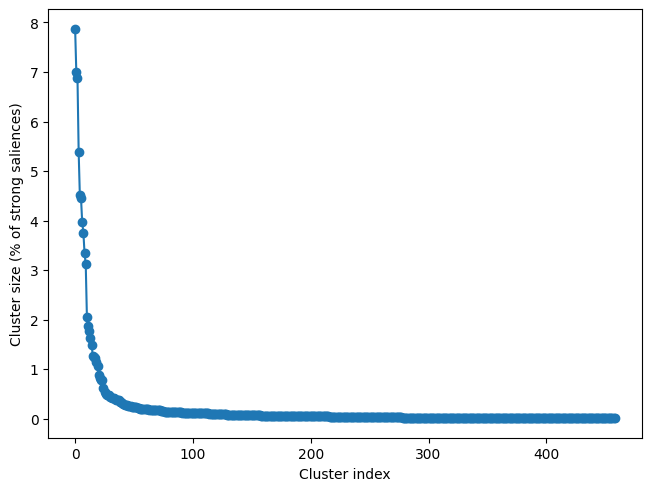

In [16]:
res.plot_cluster_sizes(lv_idx=0)

NameError: name 'mask' is not defined

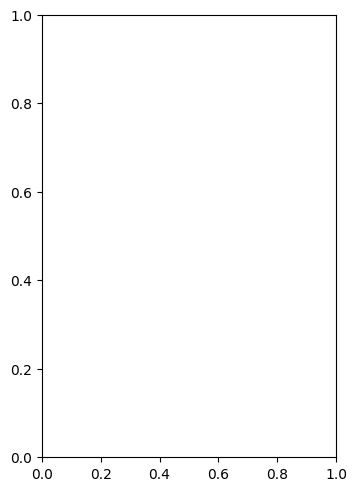

In [17]:
res.plot_cluster(lv_idx=0, cluster_idx=0)

In [9]:
epochs_mag = epochs.copy().pick('grad')
tfr = epochs_mag.compute_tfr(**tfr_kwargs).apply_baseline(mode="ratio", baseline=(None, 0))

Applying baseline correction (mode: ratio)


In [10]:
res = mne_plsc.fit_mc(tfr, between=labels)
res.add_adjacency(all_channels_adjacent=True)
res.cluster()

Clustering saliences
Computing clusters for lv_idx 0...
24 clusters


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

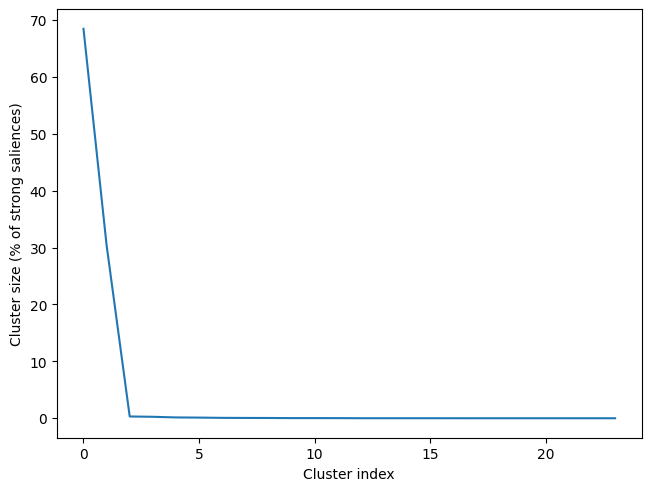

In [11]:
res.plot_cluster_sizes(lv_idx=0)

IndexError: index 101 is out of bounds for axis 0 with size 101

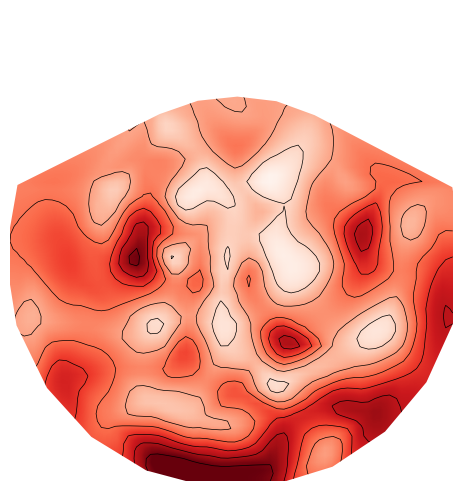

In [12]:
# res.plot_cluster_topo(lv_idx=0, cluster_idx=0)